<a href="https://colab.research.google.com/github/JvF777/inteligencia-artificial-UMC/blob/main/Dataset_FishMorph_Jo%C3%A3o_Vitor_Ferreira_Pedroso_11241103647_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

##2. Dataset


In [ ]:

!pip install -q kagglehub
import kagglehub, os

path = kagglehub.dataset_download("menegidio/fishmorph-dataset")

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "FISHMORPH_Order_Dataset.csv"))
print("Linhas:", df.shape[0], "| Colunas:", df.shape[1])

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
['FISHMORPH_Order_Dataset.csv', 'FISHMORPH_Family_Dataset.csv']
Linhas: 8342 | Colunas: 11


## 3. Análise de dados

In [ ]:

display(df.head())
display(df.tail())

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
8337,22.0,8.160515,0.742393,0.394320,0.307719,0.332283,0.793826,0.600208,0.105301,3.951881,Perciformes
8338,50.0,5.241134,0.600061,0.377792,0.293883,0.301585,0.617588,0.481677,0.133632,3.565657,Perciformes
8339,4.0,3.159920,0.453558,0.560501,0.533168,0.175106,0.470270,0.324433,0.187150,2.395070,Cyprinodontiformes
8340,140.0,4.165031,0.545773,0.115646,0.471200,0.483810,0.498305,0.223729,0.163095,2.091741,Siluriformes
8341,140.0,4.420704,0.600544,0.145919,0.422607,0.458131,0.476710,0.275952,0.179260,2.094768,Siluriformes


In [ ]:
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


 1. MBl
 2. BEl
 3. VEp
 4. REs
 5. OGp
 6. RMl
 7. BLs
 8. PFv
 9. PFs
10. CPt
11. Order


# 3.1 Tipos de dados

In [ ]:
print(df.dtypes)
print()

numericas = df.select_dtypes(include=[np.number]).columns.tolist()
nao_numericas = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numericas: {len(numericas)}")
print(f"Nao numericas: {len(nao_numericas)} {nao_numericas}")

if not nao_numericas:
    print("\nTodos os atributos sao numericos")
else:
    print("\nExistem colunas nao numericas.")

MBl      float64
BEl      float64
VEp      float64
REs      float64
OGp      float64
RMl      float64
BLs      float64
PFv      float64
PFs      float64
CPt      float64
Order     object
dtype: object

Numericas: 10
Nao numericas: 1 ['Order']

Existem colunas nao numericas.


# 3.2 Estatísticas

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
MBl,8342.0,22.004517,33.612007,1.200000,7.000000,12.600000,24.500000,800.000000
BEl,8342.0,4.452438,2.338235,1.033084,3.139102,4.038851,5.002621,43.728161
VEp,8342.0,0.549087,0.094883,0.159248,0.487993,0.546213,0.605125,1.000000
REs,8342.0,0.391665,0.132814,0.000000,0.293205,0.389429,0.486221,1.026667
OGp,8342.0,0.381768,0.194352,0.000000,0.278014,0.406904,0.516001,1.026316
RMl,8342.0,0.399786,0.302658,0.000000,0.257999,0.361436,0.490671,7.060344
BLs,8342.0,0.571818,0.117486,0.224525,0.490052,0.564739,0.648039,1.230105
PFv,8342.0,0.285316,0.155629,0.000000,0.193134,0.275039,0.368876,0.857097
PFs,8342.0,0.189343,0.056109,0.000000,0.157972,0.183497,0.215031,0.511113
CPt,8342.0,2.560795,1.016659,0.000000,1.999744,2.436329,2.919818,15.452061


## 3.3 Valores duplicados/nulos

In [ ]:
nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Porcentagem (%)": (df.isnull().mean() * 100).round(2)
})
display(nulos)

# Linhas repetidas
print("Duplicados:", df.duplicated().sum())

,Nulos,Porcentagem (%)
MBl,0,0.0
BEl,0,0.0
VEp,0,0.0
REs,0,0.0
OGp,0,0.0
RMl,0,0.0
BLs,0,0.0
PFv,0,0.0
PFs,0,0.0
CPt,0,0.0


Duplicados: 1


## 3.4 Limpeza dos dados

A verificação anterior mostrou que o dataset **não possui valores nulos**, portanto não foi necessário remover linhas nem preencher valores ausentes.

Foi encontrada **1 linha duplicada**, que foi removida.

In [ ]:
# Remove linhas duplicadas
antes = df.shape[0]
df = df.dropna().drop_duplicates().reset_index(drop=True)
depois = df.shape[0]

print(f"Linhas antes: {antes}")
print(f"Linhas depois: {depois}")
print(f"Removidas: {antes - depois}")

Linhas antes: 8342
Linhas depois: 8341
Removidas: 1


In [ ]:
## 4. Distribuição das categorias

Coluna alvo: Order
Order
Cypriniformes         1933
Perciformes           1826
Siluriformes          1800
Characiformes         1281
Cyprinodontiformes     554
Osteoglossiformes      156
Clupeiformes           104
Gymnotiformes          101
Salmoniformes           92
Atheriniformes          71
Scorpaeniformes         70
Osmeriformes            69
Synbranchiformes        48
Beloniformes            33
Tetraodontiformes       31
Pleuronectiformes       28
Acipenseriformes        23
Mugiliformes            18
Syngnathiformes         16
Anguilliformes          16
Gasterosteiformes       13
Gonorynchiformes        10
Esociformes             10
Polypteriformes          9
Lepisosteiformes         6
Percopsiformes           6
Elopiformes              5
Batrachoidiformes        4
Gadiformes               3
Gobiesociformes          3
Amiiformes               1
Ophidiiformes            1
Name: count, dtype: int64


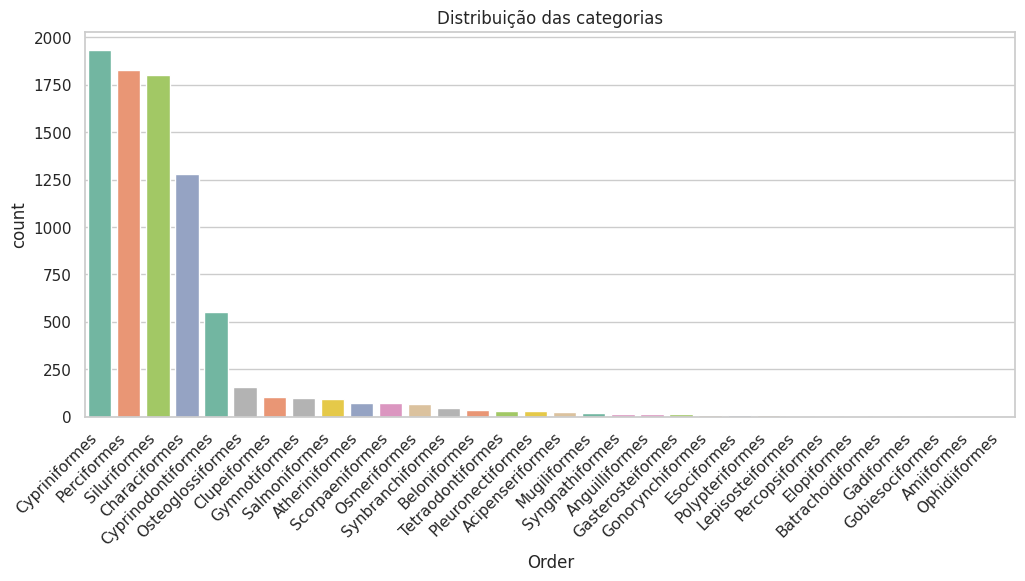

In [ ]:
# Define a coluna alvo (classe): a Ordem taxonômica do peixe
TARGET = "Order"
print("Coluna alvo:", TARGET)

# Quantidade de amostras em cada categoria
contagem = df[TARGET].value_counts()
print(contagem)

# Gráfico para melhor visualização
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x=TARGET, hue=TARGET, order=contagem.index, palette="Set2", legend=False)
plt.title("Distribuição das categorias")
plt.xticks(rotation=45, ha="right")
plt.show()

### 4.1 Filtragem das classes
A distribuição mostra **32 ordens  desbalanceadas**: as quatro maiores (Cypriniformes, Perciformes, Siluriformes e Characiformes)

**Decisão:** mantive apenas as ordens com **pelo menos 100 amostras**

- A divisão estratificada e a validação cruzada de 5 dobras exigem um número mínimo de exemplos por classe.
- Classes com pouquíssimas amostras não permitem que o modelo aprenda um padrão.
- O corte em 100 preserva 8 classes e a grande maioria dos registros.

Classes mantidas: 8 de 32
Linhas antes: 8341 | Linhas depois: 7755
Base preservada: 93.0%

Order
Cypriniformes         1933
Perciformes           1826
Siluriformes          1800
Characiformes         1281
Cyprinodontiformes     554
Osteoglossiformes      156
Clupeiformes           104
Gymnotiformes          101
Name: count, dtype: int64


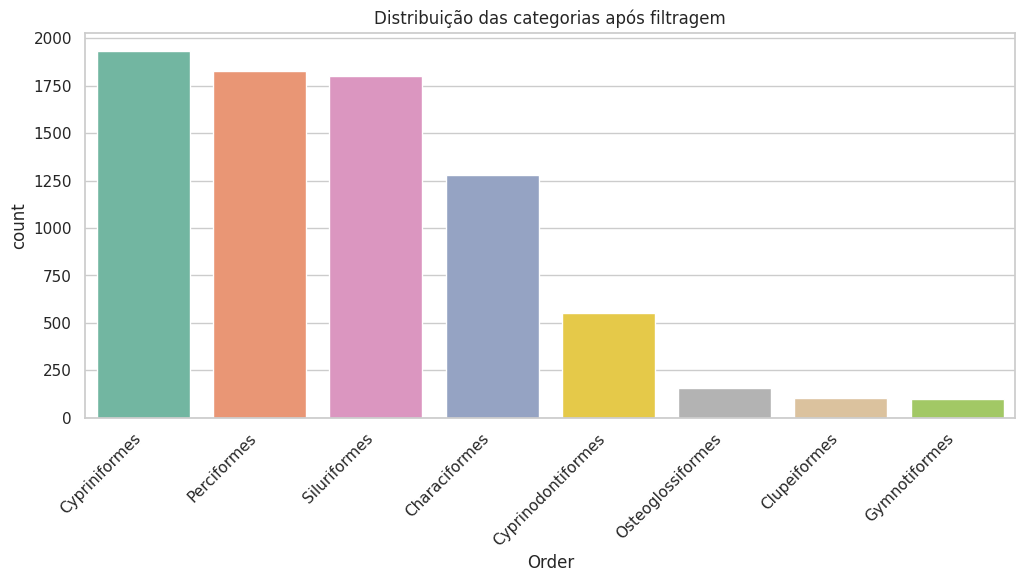

In [ ]:
MIN_AMOSTRAS = 100
classes_validas = contagem[contagem >= MIN_AMOSTRAS].index

antes = df.shape[0]
df = df[df[TARGET].isin(classes_validas)].reset_index(drop=True)

print(f"Classes mantidas: {len(classes_validas)} de {len(contagem)}")
print(f"Linhas antes: {antes} | Linhas depois: {df.shape[0]}")
print(f"Base preservada: {df.shape[0] / antes * 100:.1f}%\n")


nova_contagem = df[TARGET].value_counts()
print(nova_contagem)

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x=TARGET, hue=TARGET, order=nova_contagem.index, palette="Set2", legend=False)
plt.title("Distribuição das categorias após filtragem")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
## 5. Visualização das variáveis

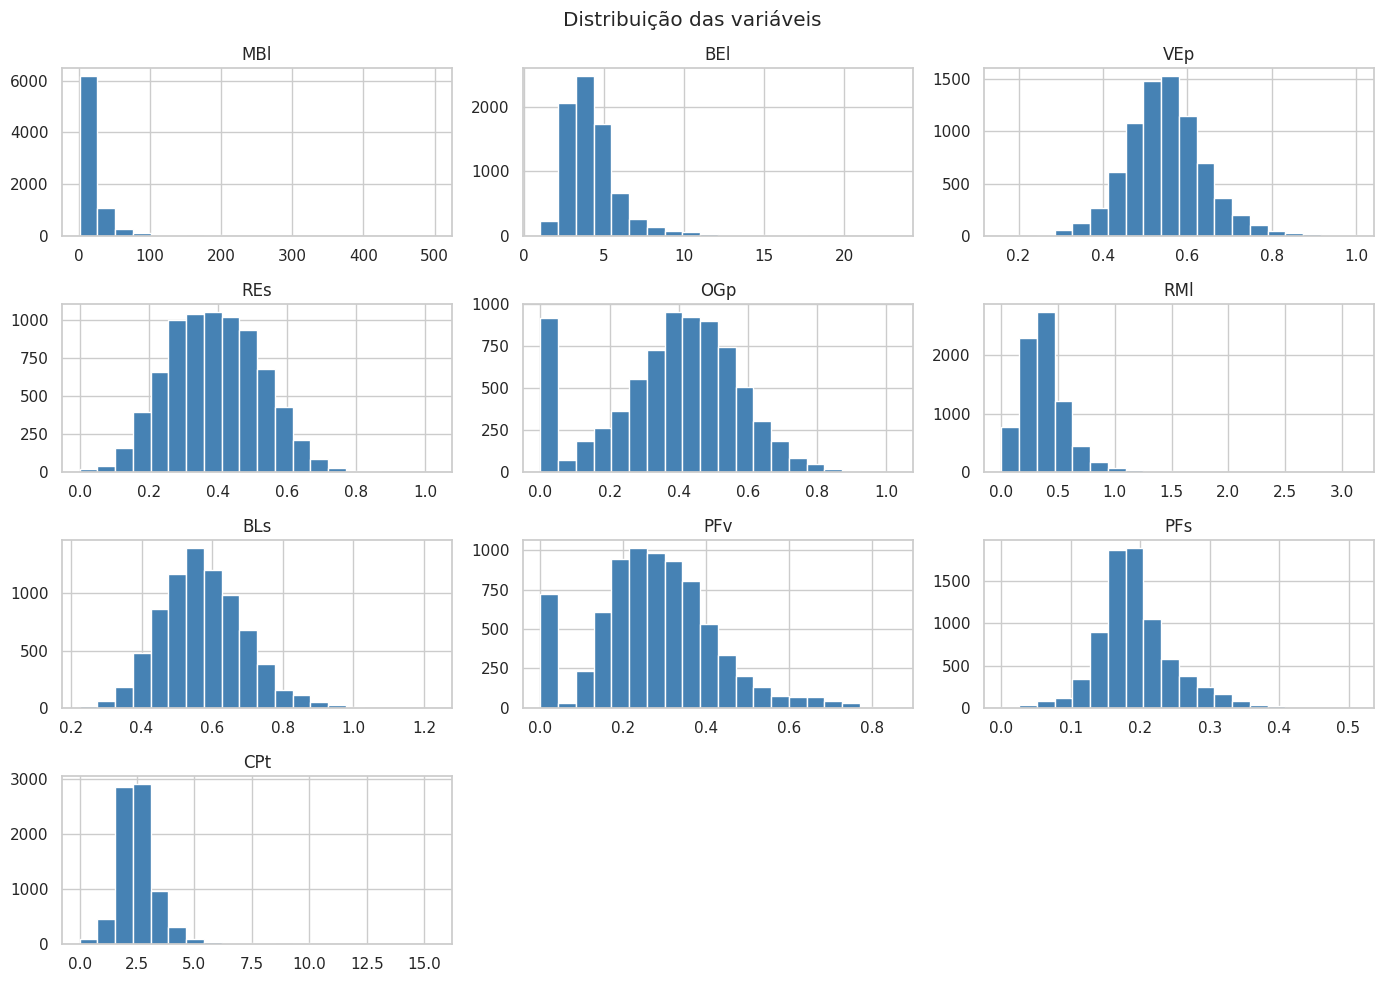

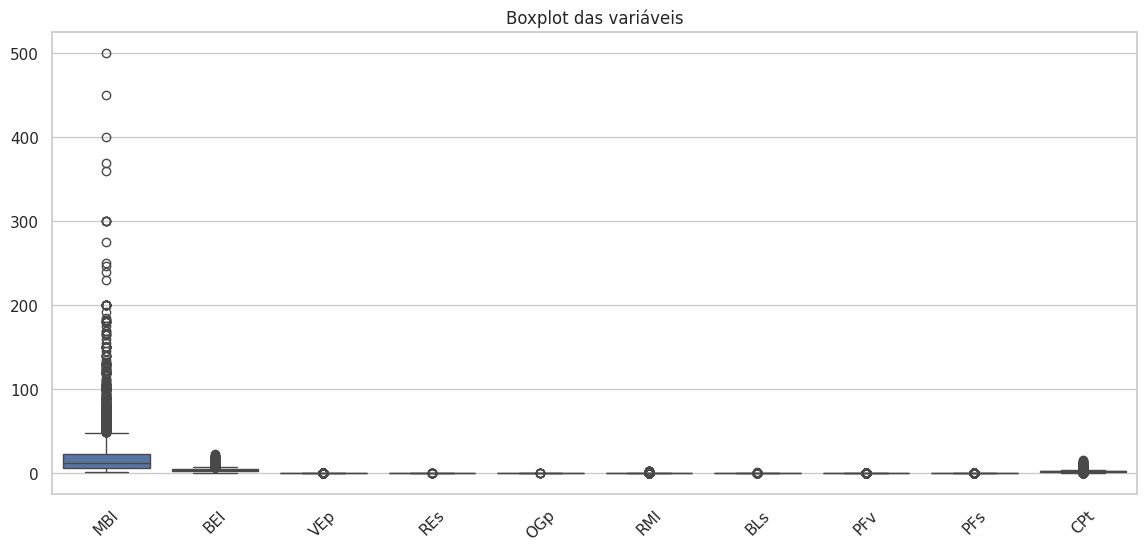

In [ ]:
# Colunas numéricas usadas como atributos (sem o alvo)
atributos = df.select_dtypes(include=np.number).columns

# Histogramas de cada atributo
df[atributos].hist(bins=20, figsize=(14, 10), color="steelblue")
plt.suptitle("Distribuição das variáveis")
plt.tight_layout()
plt.show()

# Boxplots para identificar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[atributos])
plt.title("Boxplot das variáveis")
plt.xticks(rotation=45)
plt.show()

**Análise dos histogramas:** os atributos apresentam escalas muito diferentes, com MBl chegando a 500, enquanto VEp, REs, OGp, PFv e PFs variam entre 0 e 1, o que reforça a necessidade de padronização antes do SVM. MBl, BEl, RMl e CPt são assimétricas à direita, indicando que a maioria das espécies é pequena e poucas espécies grandes aparecem como outliers. VEp, REs, BLs e PFs têm distribuição próxima da normal. OGp e PFv apresentam concentração de valores em zero,

### 5.1 Matriz de correlação

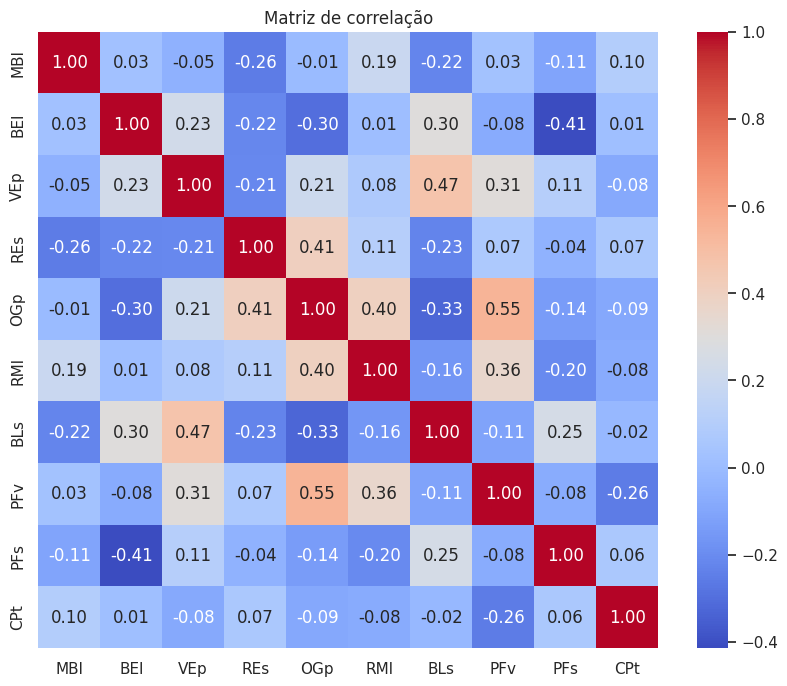

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[atributos].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlação")
plt.show()

**Análise da correlação:** as correlações entre os atributos são fracas a moderadas, com destaque para OGp e PFv (0,55), VEp e BLs (0,47) e BEl e PFs (−0,41). Como nenhum par apresenta correlação forte , não há redundância entre as variáveis, e todos os 10 atributos foram mantidos no modelo.

## 6. Divisão treino e teste

**Decisões:**
- **80% treino e 20% teste:** proporção padrão que deixa dados suficientes para treinar e uma parte separada para avaliar o modelo em dados nunca vistos.
- **stratify=y:** mantém a mesma proporção de cada classe no treino e no teste.
- **LabelEncoder:** converte as categorias de texto em números, pois o scikit-learn exige classes numéricas.
- **StandardScaler:** padroniza os atributos (média 0, desvio 1). O scaler é ajustado apenas no treino para não vazar informação do teste.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separa atributos (X) e classe (y)
X = df[atributos]

# Converte as categorias de texto em números
le = LabelEncoder()
y = le.fit_transform(df[TARGET])

# 80% treino e 20% teste, mantendo a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Padronização: aprende com o treino e aplica no teste
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (6204, 10)
Teste: (1551, 10)


## 7. Grid Search com validação cruzada

**GridSearch testados (4 valores cada, 64 combinações):**

* kernel: linear, rbf, poly e sigmoid.
* C: 0.1, 1, 10 e 100.
* gamma: 0.001, 0.01, 0.1 e 1.

 max_iter = 100.000 para limitar o tempo de combinações que demoram a convergir.


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

# Amostra estratificada do treino para acelerar o Grid Search
X_grid, _, y_grid, _ = train_test_split(
    X_train, y_train, train_size=3000, random_state=42, stratify=y_train
)
print("Amostra usada no Grid Search:", X_grid.shape)

# 4 valores diferentes para cada hiperparâmetro
param_grid = {
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
}

# Cross validation com 5 dobras estratificadas
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# max_iter limita as iterações de combinações que demoram a convergir (ex.: poly com C alto)
grid = GridSearchCV(SVC(max_iter=100000), param_grid, cv=cv,
                    scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_grid, y_grid)

# Top 10 combinações
resultados = pd.DataFrame(grid.cv_results_)[
    ["param_kernel", "param_C", "param_gamma", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
display(resultados.head(10))

Amostra usada no Grid Search: (3000, 10)
Fitting 5 folds for each of 64 candidates, totalling 320 fits


,param_kernel,param_C,param_gamma,mean_test_score,std_test_score
41,rbf,10.0,0.100,0.807667,0.012499
25,rbf,1.0,0.100,0.794000,0.013687
53,rbf,100.0,0.010,0.790667,0.015041
57,rbf,100.0,0.100,0.786333,0.009452
37,rbf,10.0,0.010,0.786333,0.015217
14,poly,0.1,1.000,0.762333,0.011576
58,poly,100.0,0.100,0.761333,0.011518
49,rbf,100.0,0.001,0.758333,0.012605
42,poly,10.0,0.100,0.752333,0.014892
32,linear,10.0,0.001,0.738667,0.008393


**Análise do Grid Search:** a melhor combinação foi o **kernel RBF com C = 10 e gamma = 0,1**, atingindo **80,77% de acurácia média** na validação cruzada, com desvio padrão de 1,25%



## 8. Melhor modelo encontrado


In [ ]:
# Retreina o melhor modelo com todo o conjunto de treino
melhor = SVC(**grid.best_params_, max_iter=100000)
melhor.fit(X_train, y_train)

print("Modelo:", melhor)
print("Melhores parametros:", grid.best_params_)
print(f"Acuracia media na cross validation: {grid.best_score_:.4f}")

Modelo: SVC(C=10, gamma=0.1, max_iter=100000)
Melhores parametros: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Acuracia media na cross validation: 0.8077


## 9. Avaliação no conjunto de teste
O modelo é avaliado nos 20% de dados separados no início, que não participaram do treino nem do Grid Search.


Acuracia no teste: 0.8143 (81.43%)

                    precision    recall  f1-score   support

     Characiformes       0.79      0.72      0.75       256
      Clupeiformes       0.44      0.33      0.38        21
     Cypriniformes       0.71      0.80      0.75       387
Cyprinodontiformes       0.84      0.87      0.86       111
     Gymnotiformes       0.86      0.95      0.90        20
 Osteoglossiformes       0.93      0.87      0.90        31
       Perciformes       0.91      0.94      0.93       365
      Siluriformes       0.85      0.77      0.81       360

          accuracy                           0.81      1551
         macro avg       0.79      0.78      0.79      1551
      weighted avg       0.82      0.81      0.81      1551



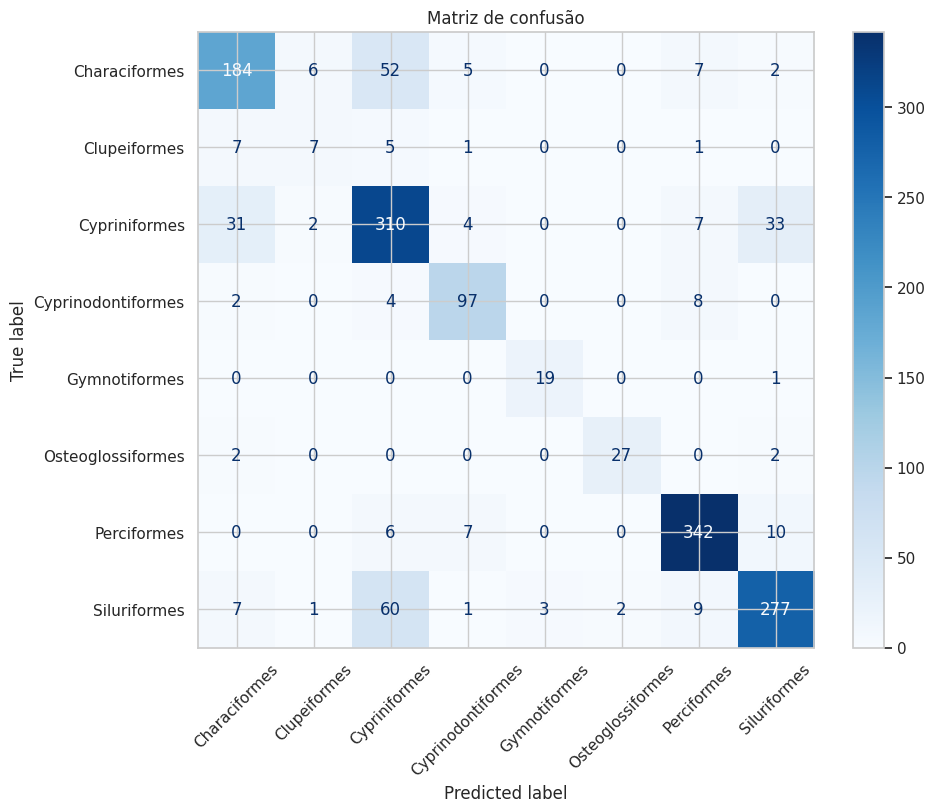

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Previsão nos dados de teste
y_pred = melhor.predict(X_test)

# Acurácia final
acc = accuracy_score(y_test, y_pred)
print(f"Acuracia no teste: {acc:.4f} ({acc*100:.2f}%)\n")

# Precisão, recall e f1 por classe
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusão")
plt.show()

## 10. Resumo final

In [ ]:
# Resumo dos resultados
print("RESUMO DO MODELO")
print("Modelo: SVM (SVC)")
print(f"Kernel: {grid.best_params_['kernel']}")
print(f"C: {grid.best_params_['C']}")
print(f"Gamma: {grid.best_params_['gamma']}")
print(f"Acuracia cross validation: {grid.best_score_:.4f}")
print(f"Acuracia teste: {acc:.4f}")

RESUMO DO MODELO
Modelo: SVM (SVC)
Kernel: rbf
C: 10
Gamma: 0.1
Acuracia cross validation: 0.8077
Acuracia teste: 0.8143


## 11. Conclusão

O melhor modelo encontrado pelo Grid Search foi um **SVM com kernel RBF, C = 10 e gamma = 0,1**, atingindo **80,77% de acurácia** na validação cruzada e **81,43% no conjunto de teste**.


Como limitação, o dataset original era fortemente desbalanceado, e foi necessário restringir a análise às 8 ordens com pelo menos 100 amostras. As classes majoritárias (Cypriniformes, Perciformes, Siluriformes e Characiformes) tendem a apresentar melhor desempenho, enquanto as ordens menores são mais confundidas, como pode ser observado na matriz de confusão.